# PREMIUR LEAGUE CLUB INVESTMENT ANALYSIS 

OBJECTIVE:

Analyze the performance of Premier League clubs using historical data and identify clubs that are: 
• Strong performers based on match outcomes and league titles 
• Still active in recent seasons 
• Potentially undervalued or overlooked by competitors 
• Generating actionable insights and recommending investment-worthy clubs.

In [3]:
# importing modules  
import pandas as pd                           # importing necessary modules for data cleaning,visualisation       
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
    
# making data frame  and importing data
df = pd.read_csv(r'C:\Users\krish\Desktop\python with AI\Premier_League_Final_Data.csv', encoding="utf-8-sig")  
  
df.head()                           # printing first 5 rows of the data

,Club,Matches Played,Win,Loss,Drawn,Goals,Clean Sheets,TeamLaunch,Winners,Runners-up,lastplayed_pl
0,1Arsenal,1182,642,252,288,2089,448,1886,3.0,6,Apr-23
1,2Aston Villa,1062,368,399,295,1306,311,1874,0.0,1,Apr-23
2,3Birmingham City,266,73,111,82,273,66,1875,0.0,NaN,May-11
3,4Blackburn Rovers,696,262,250,184,927,210,1875,1.0,1,May-12
4,5Bolton Wanderers,494,149,217,128,575,108,1874,0.0,0,May-12


In [4]:
df.tail(5)                 # last 5 rows of the data

,Club,Matches Played,Win,Loss,Drawn,Goals,Clean Sheets,TeamLaunch,Winners,Runners-up,lastplayed_pl
35,36West Bromwich Albion,494,117,238,139,510,107,1878,NaN,0,Apr-18
36,37West Ham United,1025,343,423,259,1262,266,1895,NaN,0,Apr-23
37,38Wigan Athletic,304,85,143,76,316,73,1932,NaN,0,Apr-13
38,39Wolverhampton Wanderers,334,98,151,85,353,75,1877,0.0,0,Apr-23
39,40Portsmouth,266,79,122,65,292,61,April 1898,NaN,NaN,Apr-10


In [5]:
df.describe()                    # getting the count, mean, std etc from the data

,Matches Played,Win,Loss,Drawn,Goals,Clean Sheets,Winners
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,25.000000
mean,573.750000,215.450000,210.425000,147.875000,769.000000,167.925000,1.200000
std,358.986519,194.164608,102.132364,88.873632,627.746478,135.561584,2.929733
min,190.000000,41.000000,85.000000,48.000000,181.000000,45.000000,0.000000
25%,275.000000,80.500000,127.500000,71.500000,304.500000,66.000000,0.000000
50%,443.000000,116.500000,193.500000,120.000000,462.000000,104.000000,0.000000
75%,934.750000,295.750000,263.000000,222.000000,1142.750000,244.250000,1.000000
max,1182.000000,720.000000,429.000000,329.000000,2229.000000,491.000000,13.000000


In [6]:
df.info()                # getting the datatypes and null info of the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Club            40 non-null     object 
 1   Matches Played  40 non-null     int64  
 2   Win             40 non-null     int64  
 3   Loss            40 non-null     int64  
 4   Drawn           40 non-null     int64  
 5   Goals           40 non-null     int64  
 6   Clean Sheets    40 non-null     int64  
 7   TeamLaunch      40 non-null     object 
 8   Winners         25 non-null     float64
 9   Runners-up      22 non-null     object 
 10  lastplayed_pl   40 non-null     object 
dtypes: float64(1), int64(6), object(4)
memory usage: 3.6+ KB


In [7]:
df.shape            # finding the shape of the data

(40, 11)

In [8]:
# identifying the missing values 

missing_values = df.isna().sum()
print(missing_values)          # found some missing values in winners and runner-up columns

Club               0
Matches Played     0
Win                0
Loss               0
Drawn              0
Goals              0
Clean Sheets       0
TeamLaunch         0
Winners           15
Runners-up        18
lastplayed_pl      0
dtype: int64


In [9]:
# identifying incorrect datatypes

# teamlaunch column has  incorrect format. we changed that to year format  using regex

df['TeamLaunch'] = df['TeamLaunch'].astype(str).str.extract(r'(\d{4})')[0]
df['TeamLaunch'] = pd.to_numeric(df['TeamLaunch'])                           # converting the year into numeric format

In [10]:
# changing club name from object to string and truncating the index number

df['Club']= df['Club'].str.replace('\d+', '', regex=True) # \d+ is the regex expression that removes all digits in string
df['Club'] = df['Club'].astype('string')

In [11]:
# removing null values and changing datatype of winners  

df['Winners']=df['Winners'].fillna(0)
df['Winners'] = df['Winners'].astype(int)

# removing null and incosnistant values and changing datatype of loosers 
df['Runners-up']= df['Runners-up'].fillna(0).replace('-',0)
df['Runners-up'] = df['Runners-up'].astype(int)

# changing datatype of last played cloumns

df['lastplayed_conv'] = pd.to_datetime(df['lastplayed_pl'],format="%b-%y")
df['lastplayed_conv'] = df['lastplayed_conv'].dt.year


In [12]:
#calculating sum of wins,loss and drawn 
df['total_outcome'] = df['Win']+df['Loss']+df['Drawn'] 
df['matches_check'] = np.where( df['total_outcome'] == df['Matches Played'], 'true', 'false') # we checked if the total outcome of matches is equal to matches played
#df.drop(columns = ['check'])
df["win_ratio"] = df['Win']/df['total_outcome']
df["loss_ratio"] = df['Loss']/df['total_outcome']
df["clean_sheets_ratio"] = df['Clean Sheets']/df['total_outcome']

In [13]:
# creating Win %, Draw %, Loss %

df['Win_%'] = df['Win']/df['Matches Played']*100
df['Loss_%'] = df['Loss']/df['Matches Played']*100
df['Draw_%'] = df['Drawn']/df['Matches Played']*100

In [14]:
import warnings
warnings.filterwarnings("ignore")

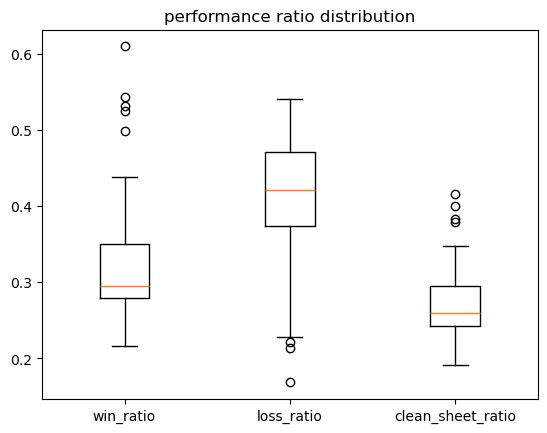

In [15]:
# box plots for win,loss and clean sheet ratio
box_plot_data = [df['win_ratio'],df['loss_ratio'],df['clean_sheets_ratio']]
plt.boxplot(box_plot_data,tick_labels=['win_ratio','loss_ratio','clean_sheet_ratio'])
plt.title('performance ratio distribution')
plt.show()


In [16]:
# box plot data 
win_median=df['win_ratio'].median()
loss_median=df['loss_ratio'].median()
clean_sheets_median=df['clean_sheets_ratio'].median()

def get_bounds(col):
    q1 = df[col].quantile(0.25)                     # calculating the quantiles and IQR to fine the bounds of the box plot
    q3 = df[col].quantile(0.75)
    IQR = q3-q1
    lower_bound = q1-1.5*IQR
    upper_bound = q3+1.5*IQR
    return lower_bound,upper_bound

low,high = get_bounds('win_ratio')                   # bounds for win ratio box plot
top_win_teams = df[(df['win_ratio']>win_median)&(df['win_ratio']>high)]

low,high = get_bounds('loss_ratio')                  # bounds for loss ratio box plot
top_loss_teams = df[(df['loss_ratio']<loss_median)&(df['loss_ratio']<low)]

low,high = get_bounds('clean_sheets_ratio')          # bounds for clean sheets ratio box plot
top_cs_teams = df[(df['clean_sheets_ratio']>clean_sheets_median)&(df['clean_sheets_ratio']>high)]

#print(top_win_teams[['Club','Win_%']])               # dominant teams
#print(top_loss_teams[['Club','Loss_%']])             # toughest teams
#print(top_cs_teams[['Club','Clean Sheets']])         # top defencive teams


win_low,win_high=get_bounds('win_ratio')
loss_low,loss_high=get_bounds('loss_ratio')
cs_low,cs_high=get_bounds('clean_sheets_ratio')
                                                     # elite teams:- who excelled in all three categories
elite_teams = df[(df['win_ratio']>win_high) &  (df['loss_ratio']<loss_low) & (df['clean_sheets_ratio']>cs_high)]
print(elite_teams[['Club','Win_%','Loss_%','Clean Sheets']])

                 Club      Win_%     Loss_%  Clean Sheets
0             Arsenal  54.314721  21.319797           448
9             Chelsea  53.130288  22.081218           473
20  Manchester United  60.965284  16.850127           491


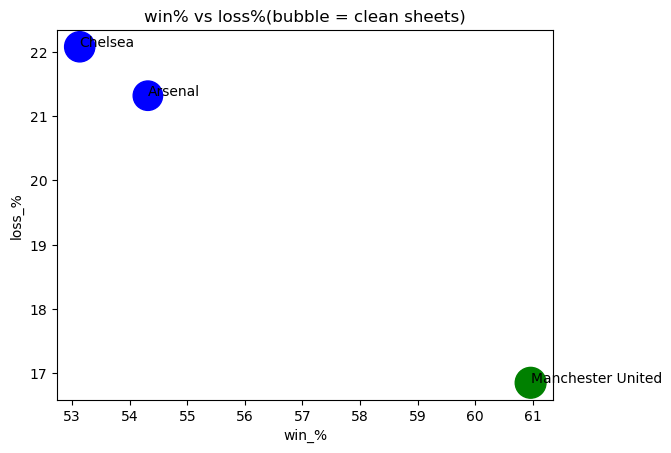

In [17]:
# scatter plot for elite teams 
colors = ['green' if x==elite_teams['Win_%'].max() else 'blue' for x in elite_teams['Win_%']]

plt.scatter(elite_teams['Win_%'],elite_teams['Loss_%'],s=elite_teams['Clean Sheets'],c=colors)
for x,y,label in zip(elite_teams['Win_%'],elite_teams['Loss_%'],elite_teams['Club']):
    plt.text(x,y,label)
    plt.xlabel('win_%')
    plt.ylabel('loss_%')
    plt.title('win% vs loss%(bubble = clean sheets)')

<Axes: >

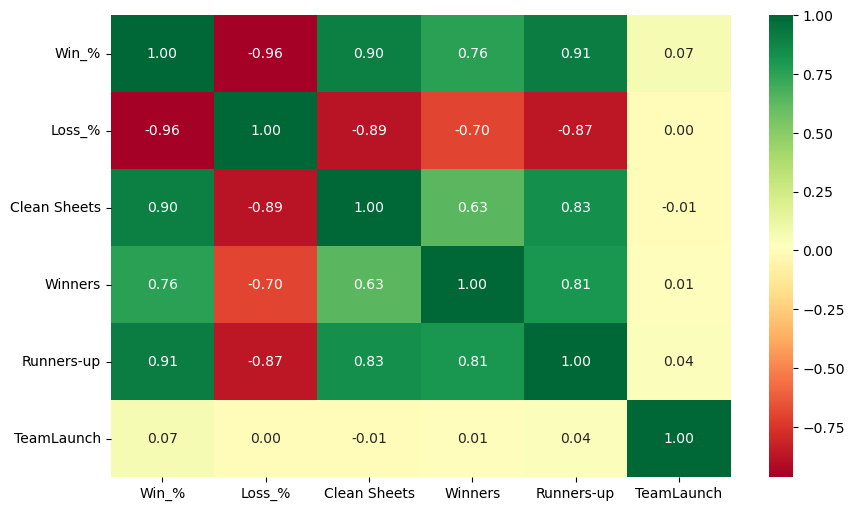

In [56]:
# correlation heatmap to find relation between columns
plt.figure(figsize=(10,6))
col=["Win_%","Loss_%","Clean Sheets","Winners","Runners-up","TeamLaunch"]
relation = df[col].corr()
sns.heatmap(relation,annot = True,cmap='RdYlGn',fmt='.2f')

                 Win_%  Clean Sheets
Win_%         1.000000      0.904484
Clean Sheets  0.904484      1.000000


<Axes: xlabel='Clean Sheets', ylabel='Win_%'>

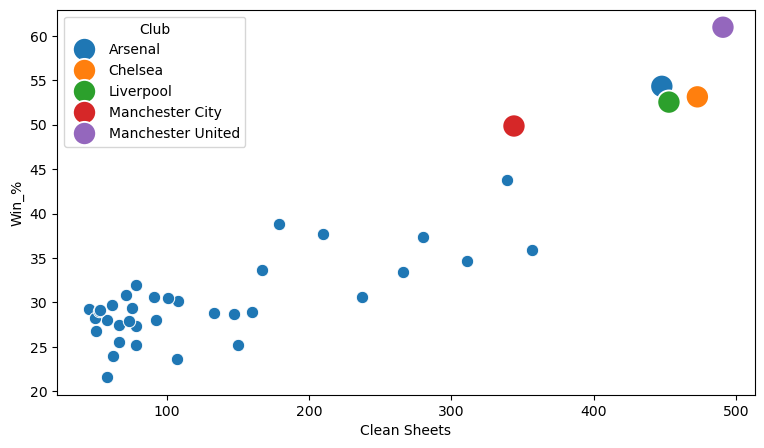

In [44]:

print(df[['Win_%','Clean Sheets']].corr())    # finding correlation between win_% and clean sheets

plt.figure(figsize=(9,5))
sns.scatterplot(data=df,
               x='Clean Sheets',
               y='Win_%',
               s=80)
top= df.nlargest(5,'points')                # top 5 teams who have higher points based on the criteria set

sns.scatterplot(data=top, 
                x='Clean Sheets',
               y='Win_%',
                hue='Club',
               s=280)


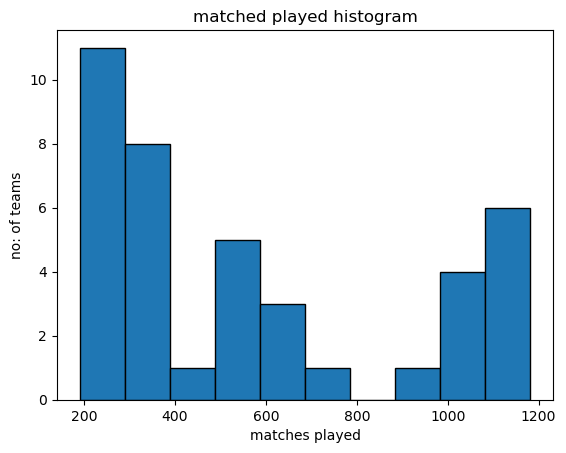

In [89]:
# hisotgram for matched played 
plt.hist(df["Matches Played"],bins=10,edgecolor="black")
plt.xlabel("matches played")
plt.ylabel("no: of teams")
plt.title("matched played histogram")
plt.show()

In [94]:
# matches played by ascending order 
df_sort = df.sort_values(by=["Matches Played"])
df_sort.reset_index(drop=True, inplace=True)
#df_sort[['Club','Matches Played','Win_%']].head()
mp_median = df_sort["Matches Played"].median()
df['efficiency']=df['Win']/df['Matches Played']

# efficient teams :- teams who playes less than avg of matches played but has considerably good win%
efficient_teams = df[(df['Matches Played']<mp_median) & (df['efficiency']>df['efficiency'].median())]
print(efficient_teams[["Club","Matches Played","Win_%","Clean Sheets","efficiency"]].sort_values(by="Matches Played"))

                   Club  Matches Played      Win_%  Clean Sheets  efficiency
32         Swansea City             266  30.827068            71    0.308271
39           Portsmouth             266  29.699248            61    0.296992
8     Charlton Athletic             304  30.592105            91    0.305921
28  Sheffield Wednesday             316  31.962025            78    0.319620
30           Stoke City             380  30.526316           101    0.305263


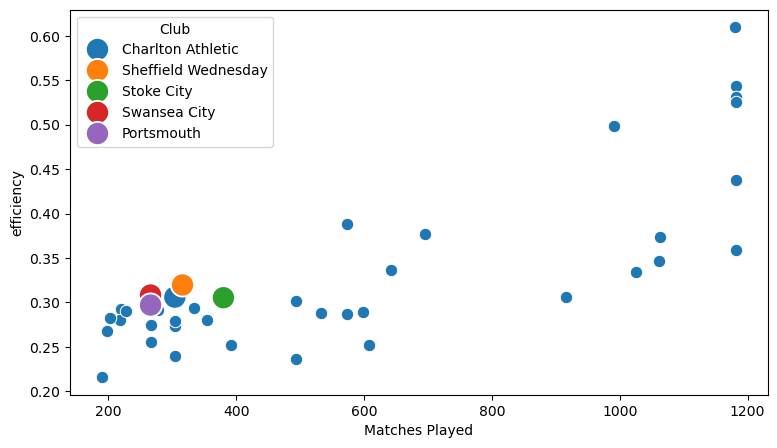

In [86]:

plt.figure(figsize=(9,5))
sns.scatterplot(data=df,
                x='Matches Played',
                y='efficiency',
                s=80)

sns.scatterplot(data=efficient_teams, 
                 x='Matches Played',
               y='efficiency',
                hue='Club',
               s=280)
plt.show()

In [21]:
# established clubs
tl_threshold = df['TeamLaunch'].quantile(0.25)              # top 25% oldest clubs   

# estd clubs:- top 25% clubs who have been long established
estd_clubs = df[(df["TeamLaunch"]<tl_threshold)].sort_values(by=["TeamLaunch"])
print(estd_clubs[["Club","TeamLaunch","Win_%","Loss_%","lastplayed_conv"]])

1877.75
                       Club  TeamLaunch      Win_%     Loss_%  lastplayed_conv
11           Crystal Palace        1861  28.759398  45.300752             2023
30               Stoke City        1863  30.526316  40.789474             2018
24        Nottingham Forest        1865  29.074890  41.409692             2023
28      Sheffield Wednesday        1867  31.962025  39.873418             2000
4          Bolton Wanderers        1874  30.161943  43.927126             2012
1               Aston Villa        1874  34.651601  37.570621             2023
3          Blackburn Rovers        1875  37.643678  35.919540             2012
2           Birmingham City        1875  27.443609  41.729323             2011
21            Middlesbrough        1876  28.745645  41.811847             2017
38  Wolverhampton Wanderers        1877  29.341317  45.209581             2023


In [22]:
# clubs with underwhelming performance despite long history or played long ago
lp_threshold = df['lastplayed_conv'].quantile(0.25) 
uv_clubs = df[(df["lastplayed_conv"]<lp_threshold)|(df["TeamLaunch"]<tl_threshold)&(df['loss_ratio']>loss_median)].sort_values(by=["TeamLaunch"])
print(uv_clubs[["Club","TeamLaunch","Win_%","Loss_%","lastplayed_conv"]])


                       Club  TeamLaunch      Win_%     Loss_%  lastplayed_conv
11           Crystal Palace        1861  28.759398  45.300752             2023
28      Sheffield Wednesday        1867  31.962025  39.873418             2000
4          Bolton Wanderers        1874  30.161943  43.927126             2012
3          Blackburn Rovers        1875  37.643678  35.919540             2012
2           Birmingham City        1875  27.443609  41.729323             2011
38  Wolverhampton Wanderers        1877  29.341317  45.209581             2023
15             Ipswich Town        1878  28.217822  45.544554             2002
10            Coventry City        1883  27.966102  40.395480             2001
12             Derby County        1884  25.563910  48.120301             2008
39               Portsmouth        1898  29.699248  45.864662             2010
8         Charlton Athletic        1905  30.592105  42.434211             2007
37           Wigan Athletic        1932  27.960526  

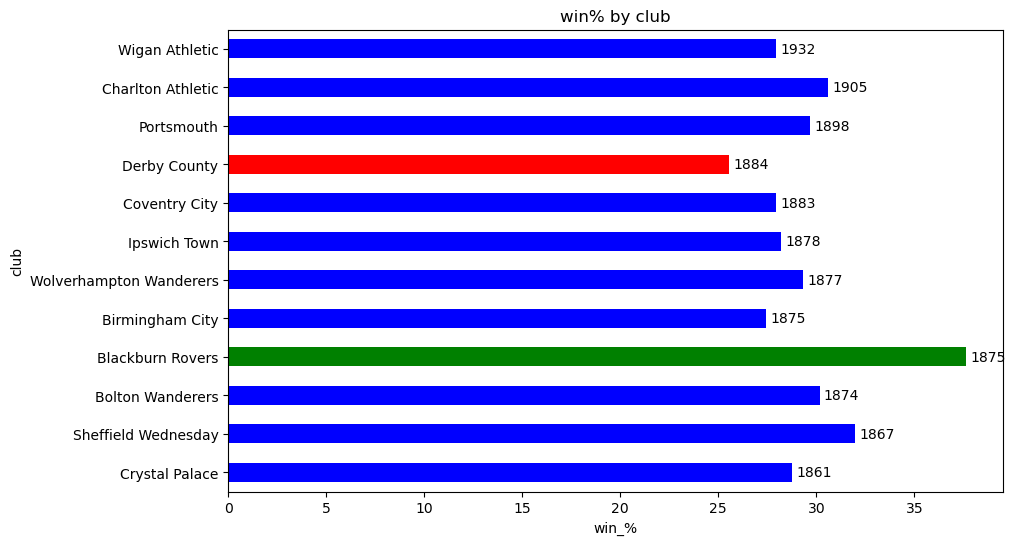

In [23]:
# horizontal bar plot for under performed clubs despite long history
colors = ['green' if x==uv_clubs['Win_%'].max() else'red'if x==uv_clubs['Win_%'].min() else 'blue' for x in uv_clubs['Win_%']]
ax = uv_clubs.plot(kind='barh',x = 'Club',y='Win_%',figsize=(10,6),legend=False,color=colors)
ax.bar_label(ax.containers[0],labels=uv_clubs['TeamLaunch'].astype(str),padding=3)
plt.xlabel('win_%')
plt.ylabel('club')
plt.title('win% by club')
plt.show()

EXPLORATORY DATA ANALYSIS 

1.	From the box plot for win ratio, loss ratio and clean sheet ratio we got the upper and lower boundary of the all three metrics. From them, we were able to detect 
•	Dominant teams  teams having higher win percent
•	Toughest teams  teams with lower loss percent
•	Defensive teams  teams with higher clean sheets
2.	From them we were able to build the ELITE teams . These are the team who have excelled in all three categories  Arsenal, Chelsea, Manchester United
3.	We have created a scatter plot for the elite teams and it clearly show how Manchester United dominated amongst all three with highest win% and lowest loss%
4.	We have created correlation heatmap to find the relation between the numerical columns. +1 represents strong positive correlation which means a directly proportional relationship and -1 represents strong inverse relationship.
From the visual, we could see strong positive relationship between win% and runner-ups , cleansheets and runner ups, win% and clean-sheets
Also we could see strong inverse relationship between loss_% and clean-sheets, loss% and winners, runners-up.
5.	The heat map tells the more the clean-sheets , the more will be the chances of winning a game and also higher the chances of ending up in finals.
6.	The heatmap clearly indicates there is a negligible to zero relationship between clean-sheets and team launch.
7.	We have built a scatter plot between win% and clean-sheets. From the plot we have highlighted top 5 clubs which evidently shown that higher clean-sheets resulted in greater win%. 
8.	From the histogram of Matches played we can conclude that more than 10 clubs played in between 200-300 matches and less than 6 clubs played in between 1000-1200 matches making them more experienced .
Swansea city and Portsmouth has got decent efficiency while playing lower matches
9.	From the horizontal bar chart between the win% and top 25% oldest clubs it is clearly evident that there is no relationship between both 


In [24]:
# scoring system based on performance metrics 

df['points']=0
q3_win= df['win_ratio'].quantile(0.75)
q1_loss = df['loss_ratio'].quantile(0.25)
q1_draw = (df['Draw_%']/100).quantile(0.25)
q3_cs = df['clean_sheets_ratio'].quantile(0.75)

df.loc[df['Matches Played']>361,'points']+=10 
df.loc[df['win_ratio']>=q3_win,'points']+=15 
df.loc[df['loss_ratio']<=q1_loss,'points']+=15 
df.loc[(df['Draw_%']/100<=q1_draw)&(df['loss_ratio']<=q1_loss),'points']+=10
df.loc[(df['clean_sheets_ratio']>=q3_cs)&(df['win_ratio']>=q3_win),'points']+=10
df.loc[df['Winners']>=1,'points']+=15
df.loc[df['Runners-up']>=1,'points']+=10
df.loc[df['lastplayed_conv']==2023,'points']+=15

clubs_100 = df[(df["points"]==100)].sort_values(by=["Winners"])
clubs_75 = df[(df["points"]==75)].sort_values(by=["Winners"])
clubs_50 = df[(df["points"]>=50)&(df["points"]<75)].sort_values(by=["TeamLaunch"])
clubs_35 = df[(df["points"]>=25)&(df["points"]<50)].sort_values(by=["TeamLaunch"])
lp_clubs = df[(df["points"]<25)&(df["points"]>0)].sort_values(by=["TeamLaunch"])
np_clubs = df[(df["points"]==0)].sort_values(by=["TeamLaunch"])

In [91]:
clubs_100[["Club","Matches Played","Win","Loss","Drawn","Goals","Clean Sheets","TeamLaunch","Winners","Runners-up","lastplayed_conv","Win_%","Loss_%","points"]].sort_values(by=["Win"])

,Club,Matches Played,Win,Loss,Drawn,Goals,Clean Sheets,TeamLaunch,Winners,Runners-up,lastplayed_conv,Win_%,Loss_%,points
19,Manchester City,991,494,283,214,1733,344,1894,6,3,2023,49.848638,28.557013,100
18,Liverpool,1182,621,270,291,2071,453,1892,1,5,2023,52.538071,22.842640,100
9,Chelsea,1182,628,261,293,2002,473,1905,5,4,2023,53.130288,22.081218,100
0,Arsenal,1182,642,252,288,2089,448,1886,3,6,2023,54.314721,21.319797,100
20,Manchester United,1181,720,199,262,2229,491,1878,13,7,2023,60.965284,16.850127,100


In [92]:
clubs_75[["Club","Matches Played","Win","Loss","Drawn","Goals","Clean Sheets","TeamLaunch","Winners","Runners-up","lastplayed_conv","Win_%","Loss_%","points"]].sort_values(by=["Win"])

,Club,Matches Played,Win,Loss,Drawn,Goals,Clean Sheets,TeamLaunch,Winners,Runners-up,lastplayed_conv,Win_%,Loss_%,points
3,Blackburn Rovers,696,262,250,184,927,210,1875,1,1,2012,37.643678,35.919540,75
33,Tottenham Hotspur,1182,518,378,286,1800,339,1882,0,1,2023,43.824027,31.979695,75


In [93]:
clubs_50[["Club","Matches Played","Win","Loss","Drawn","Goals","Clean Sheets","TeamLaunch","Winners","Runners-up","lastplayed_conv","Win_%","Loss_%","points"]].sort_values(by=["Win"])

,Club,Matches Played,Win,Loss,Drawn,Goals,Clean Sheets,TeamLaunch,Winners,Runners-up,lastplayed_conv,Win_%,Loss_%,points
16,Leeds United,574,223,202,149,784,179,1919,0,0,2023,38.850174,35.191638,65
22,Newcastle United,1063,397,391,275,1426,280,1892,0,2,2023,37.347131,36.782690,65
13,Everton,1182,424,429,329,1515,357,1878,0,0,2023,35.871404,36.294416,65


In [95]:
# finally storing the cleaned,modified and required data in the new dataframe 
league_data = df[["Club","Matches Played","Win","Loss","Drawn","Goals","Clean Sheets","TeamLaunch","Winners","Runners-up","lastplayed_conv","Win_%","Loss_%","Draw_%","points"]]